# Project 02 - Feature Engineering & Data-Centric AI

In Project 01 we improved the **model**. Here we improve the **data** - and *prove* it raises
accuracy with the model held completely fixed. This "fix the data, not the model" mindset is
called **data-centric AI**, and it's where your 10 years of ETL/data skills become a superpower.

**What you'll learn**
- What feature engineering is and *why a simple model sometimes can't win without it*.
- "Pure, row-local" features and how they avoid *train/serve skew*.
- A *data-quality gate* that fails fast on bad input (an ETL habit, applied to ML).

## The scenario
Same telecom, same goal (predict churn). But this time the real driver is hidden in an
**interaction**: customers leave when tenure and price *match* - either **short tenure + high
price** OR **long tenure + low price**. Each fact alone (tenure, or price) looks 50/50, so a
plain linear model is almost blind to it. We'll hand the model **one new column** that captures
the interaction and watch accuracy jump.

## Foundations (plain English)
- **Feature engineering** = creating new, more informative columns from raw ones.
- **Why it helps:** a linear model can only add up its inputs. It cannot, by itself, represent
  "tenure AND price together". Give it a column that already encodes that combination and it
  suddenly can.
- **Pure, row-local feature** = a feature whose value depends only on *that one row* (not on a
  global average). This matters because at serve time you score one customer at a time - a
  feature using a dataset-wide average would compute differently in production (*train/serve
  skew*). Dataset-wide stats belong *inside* the pipeline's scaler, which learns them on
  training data only.
- **Data-quality gate** = a check that rejects malformed data *before* it poisons the model.

### Cell 1 - imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
print("ready")

ready


### Cell 2 - make raw data with a HIDDEN interaction
Churn happens when `tenure < 36` and `monthly > 70` *match* (both true or both false). Notice
the contract gives a weak, *linear* hint that raw features CAN use; the match signal is the
strong one they cannot.

In [2]:
def make_raw_demo(n=4000, seed=0):
    rng = np.random.default_rng(seed)
    tenure = rng.integers(1, 72, n)
    monthly = rng.normal(70, 28, n).clip(15, 130)
    total = (tenure*monthly*rng.uniform(0.85,1.15,n)).round(2)
    contract = rng.choice(["Month-to-month","One year","Two year"], n, p=[.55,.25,.20])
    a = tenure < 36          # short tenure (about half)
    b = monthly > 70         # high price  (about half)
    match = (a == b).astype(int)                      # the hidden interaction
    logit = -1.4 + 0.8*(contract=="Month-to-month") + 2.8*match + rng.normal(0,0.40,n)
    churn = (1/(1+np.exp(-logit)) > rng.random(n)).astype(int)
    return pd.DataFrame({"tenure": tenure, "MonthlyCharges": monthly.round(2),
                         "TotalCharges": total, "Contract": contract,
                         "Churn": np.where(churn==1,"Yes","No")})

raw = make_raw_demo()
raw.head()

,tenure,MonthlyCharges,TotalCharges,Contract,Churn
0,61,113.03,7281.87,Month-to-month,No
1,46,40.71,1658.04,Month-to-month,Yes
2,37,51.63,1864.39,Month-to-month,Yes
3,20,50.87,900.28,Month-to-month,Yes
4,22,91.97,1833.64,Two year,No


### Cell 3 - quick look + churn rate

In [3]:
print("shape:", raw.shape)
print(raw["Churn"].value_counts(normalize=True).round(3))

shape: (4000, 5)
Churn
Yes    0.554
No     0.446
Name: proportion, dtype: float64


### Cell 4 - a data-quality gate (fail fast on bad data)
Before training, we validate the input: required columns exist, not too many nulls, numbers in
range. If anything is off we raise an error instead of silently training on garbage. This is
data-engineering "reject the bad batch" instinct.

In [4]:
class DataQualityError(AssertionError): pass

def validate(df, required, max_null=0.2, ranges=None):
    missing = [c for c in required if c not in df.columns]
    if missing: raise DataQualityError(f"missing columns: {missing}")
    nulls = df[required].isna().mean()
    bad = nulls[nulls > max_null]
    if len(bad): raise DataQualityError(f"too many nulls: {bad.to_dict()}")
    for col,(lo,hi) in (ranges or {}).items():
        if col in df and ((df[col]<lo)|(df[col]>hi)).any():
            raise DataQualityError(f"{col} out of range [{lo},{hi}]")
    print(f"[dq] OK - {len(df)} rows passed {len(required)} checks")
    return True

validate(raw, ["tenure","MonthlyCharges","TotalCharges","Contract","Churn"],
         ranges={"tenure":(0,80), "MonthlyCharges":(0,200)})

[dq] OK - 4000 rows passed 5 checks


True

### Cell 5 - the experiment setup: ONE fixed model, measured by cross-validation
We freeze a single logistic regression. The only thing we will change is the *features*. So any
difference in score is caused purely by the data - a clean A/B test for a data change.

In [5]:
def split_xy(df, target="Churn"):
    y = (df[target]=="Yes").astype(int)
    X = df.drop(columns=[target])
    num = X.select_dtypes(include="number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    return X, y, num, cat

def build_pipeline(num, cat, model):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat)])
    return Pipeline([("pre", pre), ("model", model)])

def cv_auc(df):
    X, y, num, cat = split_xy(df)
    pipe = build_pipeline(num, cat, LogisticRegression(max_iter=1000))
    return cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean()

auc_raw = cv_auc(raw)
print(f"AUC with RAW features = {auc_raw:.3f}")

AUC with RAW features = 0.744


### Cell 6 - engineer ONE key feature (and a few helpers), then re-measure
`tenure_price_match` encodes the hidden interaction as a single 0/1 column. All features here
are **row-local** (fixed thresholds, no dataset-wide averages) so they behave the same in
production.

In [6]:
def make_features(df):
    out = df.copy()
    out["tenure_price_match"] = ((out["tenure"]<36) == (out["MonthlyCharges"]>70)).astype(int)
    out["charges_per_tenure"] = out["TotalCharges"]/(out["tenure"]+1)
    out["is_new"] = (out["tenure"]<6).astype(int)
    out["is_month_to_month"] = (out["Contract"]=="Month-to-month").astype(int)
    return out

eng = make_features(raw)
auc_eng = cv_auc(eng)
print(f"AUC with ENGINEERED features = {auc_eng:.3f}")
print(f"data-centric lift = {auc_eng-auc_raw:+.3f}  (same model, better data)")

AUC with ENGINEERED features = 0.833


data-centric lift = +0.090  (same model, better data)


### Cell 7 - diagram: the lift from feature engineering
Same model, two feature sets. The engineered bar should clearly beat the raw bar - that gap is
the value you added by improving the data alone.

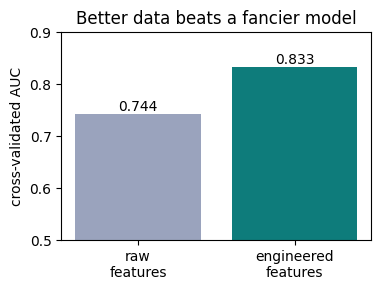

In [7]:
plt.figure(figsize=(4,3))
bars = plt.bar(["raw\nfeatures","engineered\nfeatures"], [auc_raw, auc_eng],
               color=["#9aa3bd","#0e7c7b"])
plt.ylim(0.5, 0.9); plt.ylabel("cross-validated AUC")
plt.title("Better data beats a fancier model")
for b,v in zip(bars,[auc_raw,auc_eng]):
    plt.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()

### Cell 8 - diagram: SEE the hidden interaction
We bin tenure and price into a grid and colour each cell by its churn rate. The bright cells
form a *checkerboard* (low-tenure+high-price and high-tenure+low-price) - that's the interaction
a linear model can't read from the raw columns, but `tenure_price_match` captures in one number.

/sessions/youthful-nifty-lovelace/tmp/ipykernel_10/1991244239.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grid = r.groupby([pb, tb])["churn"].mean().unstack()


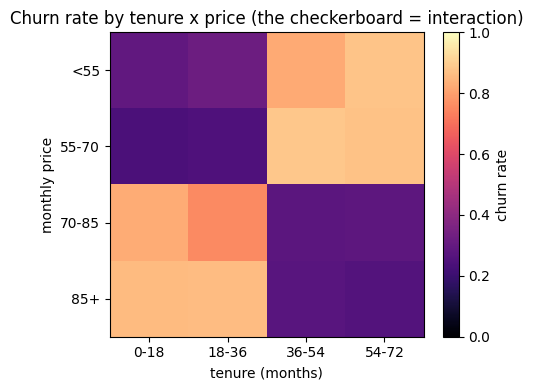

In [8]:
r = raw.copy()
r["churn"] = (r["Churn"]=="Yes").astype(int)
tb = pd.cut(r["tenure"], bins=[0,18,36,54,72], labels=["0-18","18-36","36-54","54-72"])
pb = pd.cut(r["MonthlyCharges"], bins=[0,55,70,85,140], labels=["<55","55-70","70-85","85+"])
grid = r.groupby([pb, tb])["churn"].mean().unstack()
plt.figure(figsize=(5,4))
im = plt.imshow(grid.values, cmap="magma", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, label="churn rate")
plt.xticks(range(len(grid.columns)), grid.columns); plt.yticks(range(len(grid.index)), grid.index)
plt.xlabel("tenure (months)"); plt.ylabel("monthly price")
plt.title("Churn rate by tenure x price (the checkerboard = interaction)")
plt.tight_layout(); plt.show()

## What just happened (recap)
- We hid the signal in an **interaction** that raw linear features can't represent.
- We froze the model and only changed the **features** - a clean A/B test.
- One engineered column lifted AUC by a clear margin: **data-centric AI** in action.
- We added a **data-quality gate** and kept features **row-local** to avoid train/serve skew.

## Extensions
- **Add your own feature** (e.g. `spend_band`) and re-run cells 6-7. Did AUC move?
- **Break the gate:** set a value out of range and watch `validate` stop the run.
- **Production:** in real life these features become a *DVC pipeline stage* + GitHub Actions CI
  (see the project README/LESSON) so every result is reproducible and tested.

## Mini-glossary
**data-centric AI** improve the data not the model - **feature engineering** new informative
columns - **interaction** signal that needs two inputs together - **row-local feature** depends
only on one row - **train/serve skew** features computed differently in training vs production -
**data-quality gate** reject bad data early.

Next: **Project 03 - Neural Networks from scratch** (backprop by hand).